# Simple model

We simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC and normalizing flows.

In [1]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import math 
import matplotlib.pyplot as plt
from typing import Iterable

from src.helpers import plot_trace
from src.simulator import BurstSimulator, Model

In [20]:
time = np.linspace(0, 1.0, 1000)
N = 1

amp  = 100.0
t0   = 0.4
rise = 0.03
skew = 5.0

burstparams = {
    't0'   : [t0],
    'amp'  : [amp],
    'rise' : [rise],
    'skew' : [skew]
}

ybkg = 5.0

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
noise_free_model, simulated_counts = simulator.simulate_burst(return_model=True)

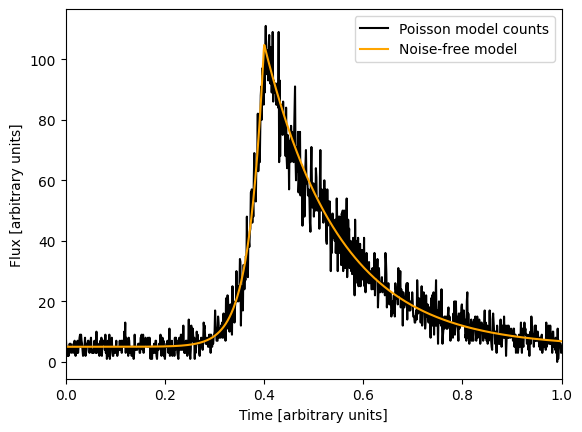

In [21]:
simulator.plot_burst()
plt.show()

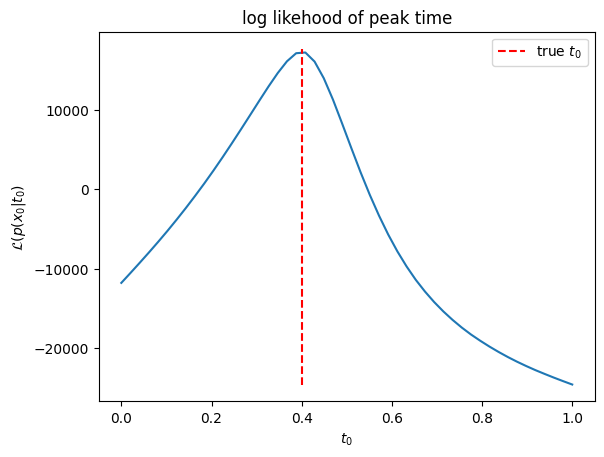

In [22]:
def log_likelihood(t0: float, modelparams, simulated_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
 
    # update model parameters
    modelparams['burstparams']['t0'] = [t0]

    # find noise-free flux
    model_counts = Model(**modelparams).get_flux()
    
    # likelihood of the observed counts under this model
    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(simulated_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in simulated_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

true_t0 = simulator.get_true('t0')

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood(t0, modelparams, simulated_counts) for t0 in t0s]

plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()

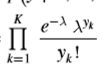

In [23]:
nwalkers = 20
ndim = 1
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_prob(t0: Iterable[float], *args) -> float:
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0 < 0 or t0 > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[modelparams, simulated_counts])

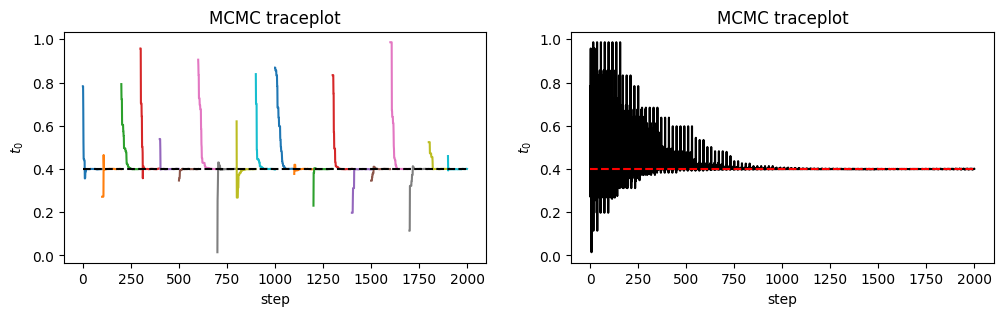

In [24]:
# burn-in 
burn_steps = 100
state = sampler.run_mcmc(p0, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

In [25]:
steps = 1000
sampler.run_mcmc(state, 1000)

State([[0.40010073]
 [0.40004815]
 [0.4002405 ]
 [0.40046336]
 [0.3997875 ]
 [0.39871771]
 [0.39967315]
 [0.39940151]
 [0.39948644]
 [0.40022367]
 [0.39968681]
 [0.39887628]
 [0.39973541]
 [0.40051038]
 [0.40058554]
 [0.40001798]
 [0.40036588]
 [0.39939957]
 [0.39882925]
 [0.39971878]], log_prob=[17310.818206   17310.82961047 17310.79541841 17310.55150782
 17310.90899145 17309.4487099  17310.95579497 17311.09620376
 17311.04788797 17310.79758238 17310.94982361 17309.80943459
 17310.92940826 17310.38026699 17310.10913103 17310.83685479
 17310.78430335 17311.09735446 17309.70099662 17310.9362464 ], blobs=None, random_state=('MT19937', array([4034695081, 1642043028, 3114972934,   64033309, 1679737865,
       1542615134,  583495420, 1357174118, 4290121089, 2838853232,
       3568224717,  325707594, 3953752851,  366989771,  520746927,
       2808167262, 1426497388, 2753262433, 1018624886,   38919963,
       3143527541, 2834896283, 2649376751, 2080971243, 2186987065,
       3773431716,  1158

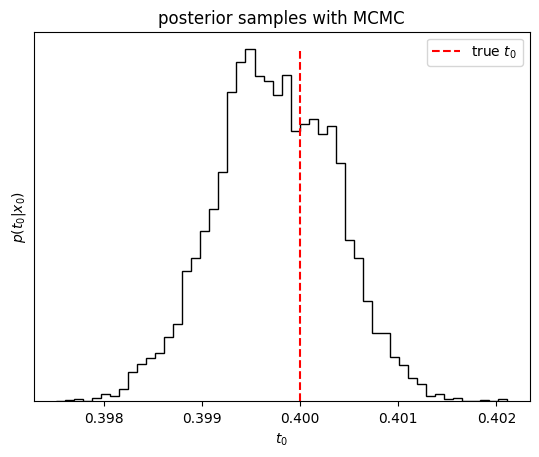

In [26]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines(true_t0,  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

In [27]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check
# add plots where you overlay samples from the posterior on the data

Mean acceptance fraction: 0.801


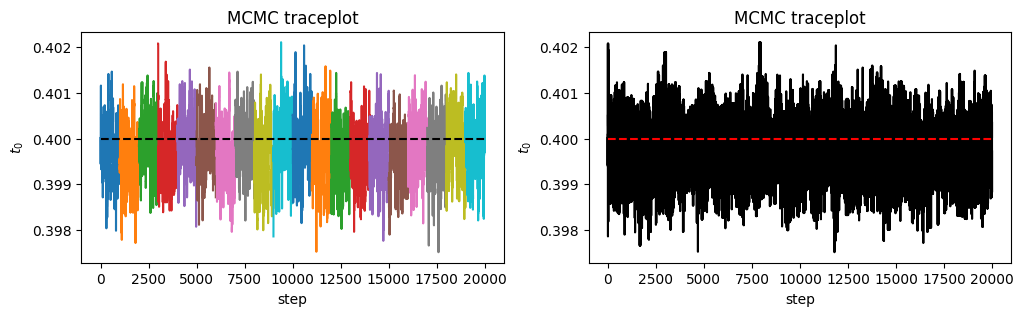

In [28]:
# trace plot
plot_trace(sampler, steps, true_t0)
plt.show()

TypeError: 'Axes' object is not subscriptable

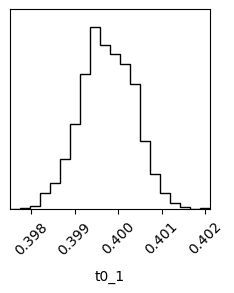

In [30]:
from corner import corner

fig = corner(samples, labels=["t0_1"], truths=[0.4])

# Two peaks

In [67]:
time = np.linspace(0, 1, 1000)
N = 2

amp = 160.0
t0 = 0.1
rise = 0.03
skew = 5
ybkg = 5.0

burstparams = {
    't0'   : [t0, t0+0.5],
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
x_model, x_counts = simulator.simulate_burst(return_model=True)

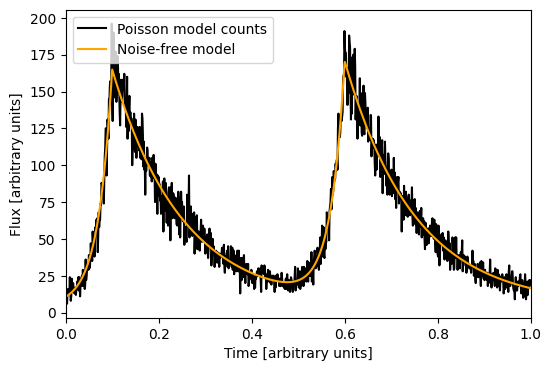

In [68]:
plt.figure(figsize=(6,4))
simulator.plot_burst()
plt.show()

In [69]:
def log_likelihood(t0: Iterable[float], modelparams: dict, x_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
 
    # update model parameters
    modelparams['burstparams']['t0'] = t0

    # find noise-free flux
    model_counts = Model(
        time       = modelparams['time'], 
        ncomp      = modelparams['ncomp'], 
        burstparams= modelparams['burstparams'], 
        ybkg       = modelparams['ybkg']
    ).get_flux()
    
    # likelihood of the observed counts under this model
    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L


def log_prob(t0, *args):
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0.any() < 0 or t0.any() > 1:
        return -np.inf
        
    # peak time of first peak should be smaller than second peak etc. etc.
    if t0[0] > t0[1]:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

nwalkers = 30
ndim = 2
p0 = np.sort(np.random.rand(nwalkers, ndim), axis=1)  # initial position of the walkers, SAMPLE FROM THE PRIOR, SO ENSURE t0_1 < t0_2

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
# mixture of moves to improve sampling in multimodal posterior
moves = [
    (emcee.moves.StretchMove(),  0.0),   # 40% stretch
    (emcee.moves.DEMove(), 0.8),         # 40% differential evolution
    (emcee.moves.DESnookerMove(), 0.2),  # 20% snooker
]
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[modelparams, x_counts], moves=moves)

In [70]:
# burn-in of 100 steps
burn_steps = 300
steps = 2000

sampler.reset()
state = sampler.run_mcmc(p0, burn_steps)

sampler.reset()
sampler.run_mcmc(state, steps)

State([[0.10084674 0.59739005]
 [0.10231811 0.59770763]
 [0.10131695 0.59747891]
 [0.10237243 0.59812925]
 [0.10180607 0.59800687]
 [0.10209102 0.59756771]
 [0.10123107 0.59813809]
 [0.10191778 0.59748315]
 [0.10133747 0.597642  ]
 [0.10109095 0.59848447]
 [0.10085823 0.59775207]
 [0.1015367  0.59767178]
 [0.10266399 0.59767617]
 [0.10227017 0.59778025]
 [0.10125877 0.59820003]
 [0.10136783 0.59756226]
 [0.101963   0.59886301]
 [0.10192413 0.59794055]
 [0.10155364 0.59810608]
 [0.10181563 0.59793447]
 [0.10229584 0.59829641]
 [0.10128766 0.59766404]
 [0.10149581 0.59673754]
 [0.10179002 0.59802339]
 [0.10086008 0.59772352]
 [0.10212793 0.59776819]
 [0.1017708  0.59821765]
 [0.10125207 0.5984697 ]
 [0.10076016 0.59815083]
 [0.1020401  0.59835712]], log_prob=[53410.22038857 53410.24569108 53411.5475715  53409.20207104
 53411.10889663 53411.73501425 53411.049431   53411.41200293
 53411.89684752 53410.60104198 53410.71695118 53411.7674755
 53408.14127674 53410.41576744 53410.94633925 53411

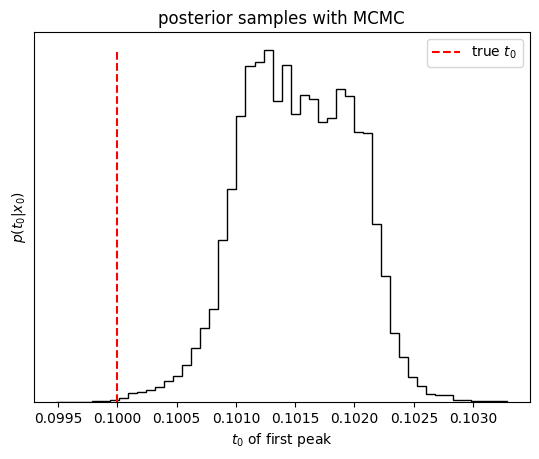

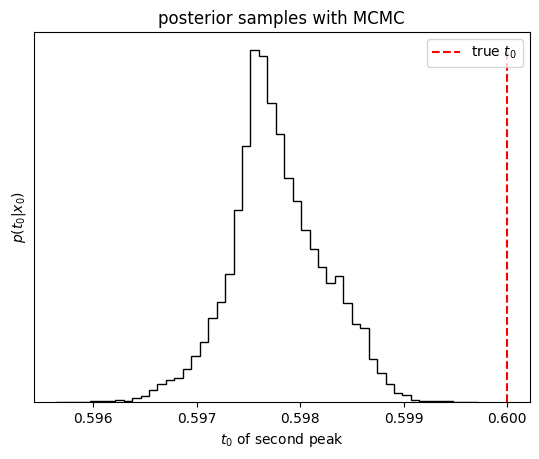

array([[0.10126758, 0.5979375 ],
       [0.10196287, 0.59811454],
       [0.10167943, 0.59798946],
       ...,
       [0.10125207, 0.5984697 ],
       [0.10076016, 0.59815083],
       [0.1020401 , 0.59835712]])

In [71]:
samples = sampler.get_chain(flat=True)
true_t0 = simulator.get_true('t0')

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines(true_t0[0],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of first peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

frequencies, _, _ = plt.hist(samples[:, 1], 50, color="k", histtype="step")
plt.vlines(true_t0[1],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_{0}$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of second peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

samples

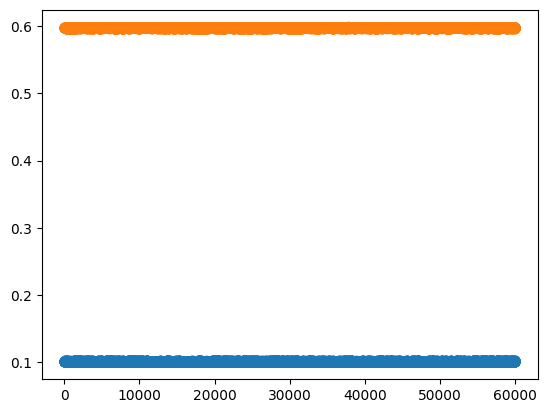

In [72]:
plt.plot(sampler.get_chain(flat=True), 'o')

In [41]:
# Normalizing flow

# generate bunch of training data (all params fixed except t0?)

# generate posterior using normalizing flow ?

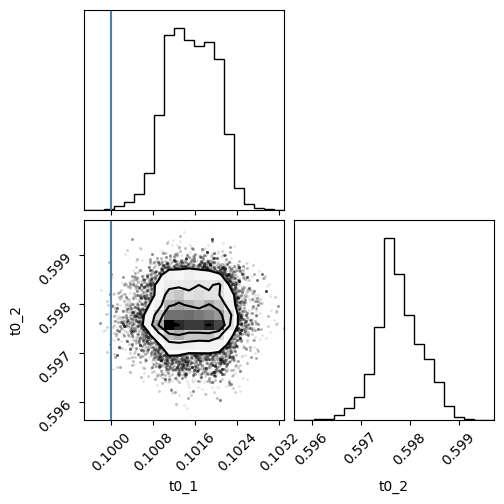

In [73]:
from corner import corner

fig = corner(samples, labels=["t0_1", "t0_2"], truths=true_t0)

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

Mean acceptance fraction: 0.396


Text(0.5, 0, 'step number')

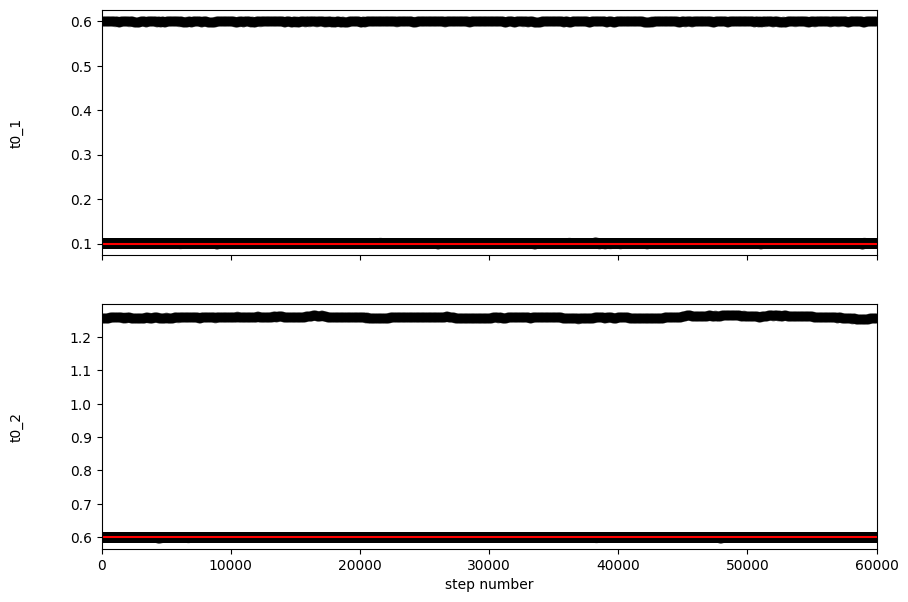

In [59]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
labels = ["t0_1", "t0_2"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples[:, i], "ko", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.hlines([true_t0[i]], xmin=0, xmax=2*nwalkers*steps, color='red')
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

[0.60050853 1.26605621] -7617.180677692901
[0.10124501 0.60011327] 18855.32169163502
[0.10130251 0.59955187] 18855.408655246763
[0.10106955 0.60009713] 18855.525823465257
[0.10124031 0.60029277] 18855.180788814847
[0.10131141 0.59946855] 18854.70135318367
[0.10125729 0.59953209] 18855.3654784081
[0.10175107 0.60027472] 18853.948506038854
[0.10129044 0.60002473] 18855.289450201046
[0.10203587 0.60030848] 18853.33944500814
[0.10061499 0.60058611] 18852.29250034892
[0.10143241 0.59986844] 18855.10210080615
[0.10111729 0.5999802 ] 18855.809442217782
[0.10072926 0.60037005] 18853.119288799702
[0.10178589 0.59962305] 18854.612326859715
[0.10182625 0.59972249] 18854.383160170415
[0.10087152 0.60042348] 18853.983427810657
[0.10179728 0.5996269 ] 18854.582124872744
[0.10146533 0.59943146] 18854.00754681455
[0.10098259 0.60049985] 18854.655130743122
[0.10134719 0.59968878] 18855.55637107916
[0.10103175 0.59967107] 18855.79167711499
[0.10084793 0.59995091] 18854.2455588632
[0.10110112 0.59965292]

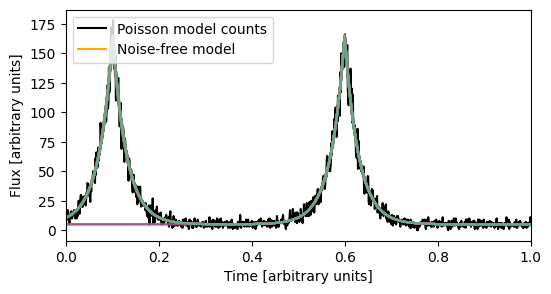

In [60]:
# Draw samples from posterior and overlay onto simulated data
# get t01 and t02 from the samples from the sampler and 
samples.shape

plt.figure(figsize=(6,3))
simulator.plot_burst()

for _ in range(100):
    random_index = np.random.randint(low=0, high=len(samples))
    random_sample = samples[random_index]
    burstparams['t0'] = random_sample
    model = Model(time, N, burstparams, ybkg).get_flux()
    print(random_sample, log_likelihood(random_sample, modelparams, x_counts))
    plt.plot(time, model, alpha=0.5)

In [29]:
simulator.get_true('skew')
print(modelparams)

{'time': array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307

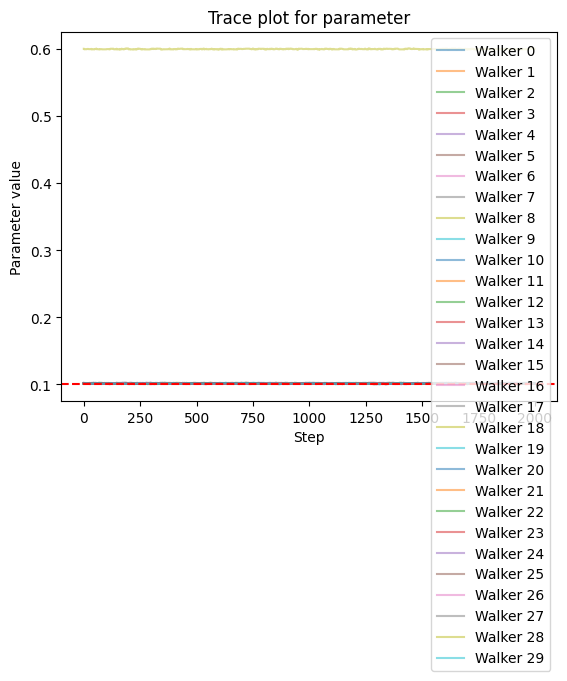

[[0.63215013 0.93876304]
 [0.13954626 0.77834518]
 [0.19408271 0.41268349]
 [0.25874019 0.64568004]
 [0.36681453 0.65884475]
 [0.22563232 0.54117612]
 [0.77009039 0.92043547]
 [0.65519095 0.77246285]
 [0.13420907 0.56045825]
 [0.0088547  0.21380784]
 [0.01744812 0.26830324]
 [0.28899468 0.9635955 ]
 [0.30265628 0.35229187]
 [0.27169294 0.54189957]
 [0.67788866 0.78511745]
 [0.74895838 0.92294023]
 [0.47648058 0.56930667]
 [0.00744421 0.44460183]
 [0.00884344 0.57491401]
 [0.46522029 0.86781416]
 [0.04356366 0.82677885]
 [0.46290791 0.7831117 ]
 [0.10529773 0.13736173]
 [0.37737346 0.78929594]
 [0.22554796 0.8190292 ]
 [0.11567175 0.27622382]
 [0.60622173 0.85868122]
 [0.37518894 0.98738032]
 [0.29473927 0.30304621]
 [0.14988872 0.74173493]]


In [61]:
n_walkers, n_steps, n_params = sampler.chain.shape
param_index = 0
true_value = 0.1
for i in range(n_walkers):
    plt.plot(sampler.chain[i, :, param_index], alpha=0.5, label=f'Walker {i}')
plt.axhline(true_value, color='red', linestyle='--')
plt.xlabel("Step")
plt.ylabel("Parameter value")
plt.title("Trace plot for parameter")
plt.legend()
plt.show()

print(p0)

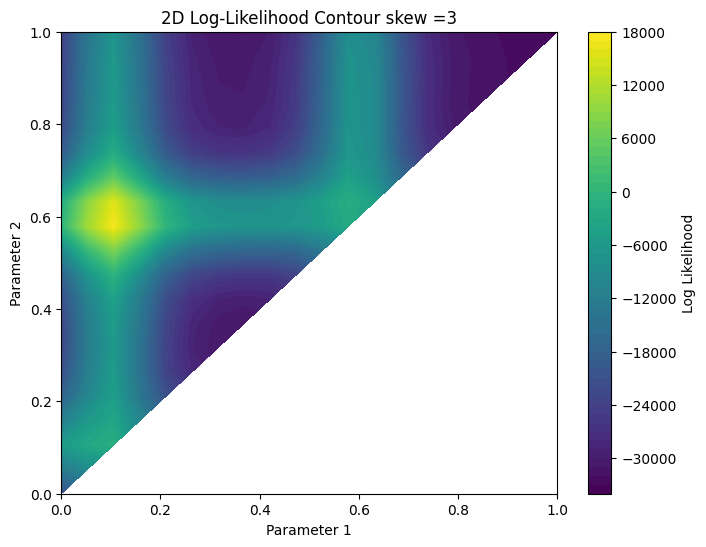

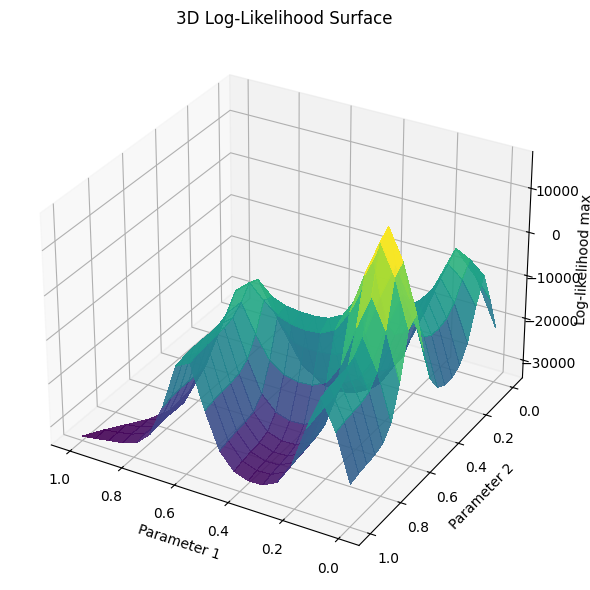

In [ ]:
time = np.linspace(0, 1, 1000)
N = 2

amp = 160.0
t0 = 0.1
rise = 0.03
skew = 1
ybkg = 5.0

burstparams = {
    't0'   : [t0, t0+0.5],
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
x_model, x_counts = simulator.simulate_burst(return_model=True)

t0_1_range = np.linspace(0, 1, 20)
t0_2_range = np.linspace(0, 1, 20)

# create a meshgrid 
t0_1, t0_2 = np.meshgrid(t0_1_range, t0_2_range)
Z = np.zeros_like(t0_1)

# Loop through the grid and evaluate log_prob
for i in range(t0_1.shape[0]):
    for j in range(t0_1.shape[1]):
        theta = np.array([t0_1[i, j], t0_2[i, j]])
        Z[i, j] = log_prob(theta, modelparams, x_counts)  # Or use log_likelihood if separate

# Plot the contour 
plt.figure(figsize=(8, 6))
contour = plt.contourf(t0_1, t0_2, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='Log Likelihood')
plt.xlabel('Parameter 1')
plt.ylabel('Parameter 2')
plt.title('2D Log-Likelihood Contour skew =3')
plt.show()

############# 3D- plot #######################3

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# plot the surface
surf = ax.plot_surface(
    t0_1, t0_2, Z,
    rstride=1, cstride=1,
    cmap='viridis',
    linewidth=0, antialiased=False,
    alpha=0.9
)

# add a color‐bar
m = plt.cm.ScalarMappable(cmap='viridis')
m.set_array(Z)
# fig.colorbar(m, shrink=0.5, aspect=10, label='Shifted log-likelihood')

# labels and view angle
ax.set_xlabel('Parameter 1')
ax.set_ylabel('Parameter 2')
ax.set_zlabel('Log-likelihood max')
ax.set_title('3D Log-Likelihood Surface')
ax.view_init(elev=30, azim=120)

plt.tight_layout()
plt.show()

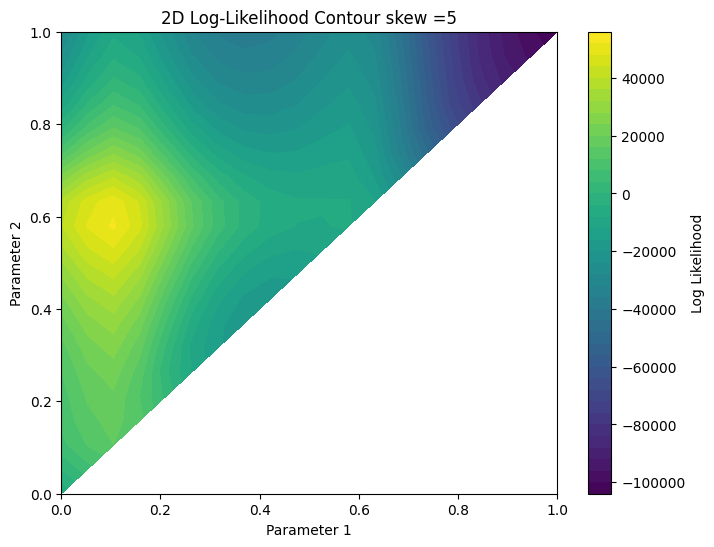

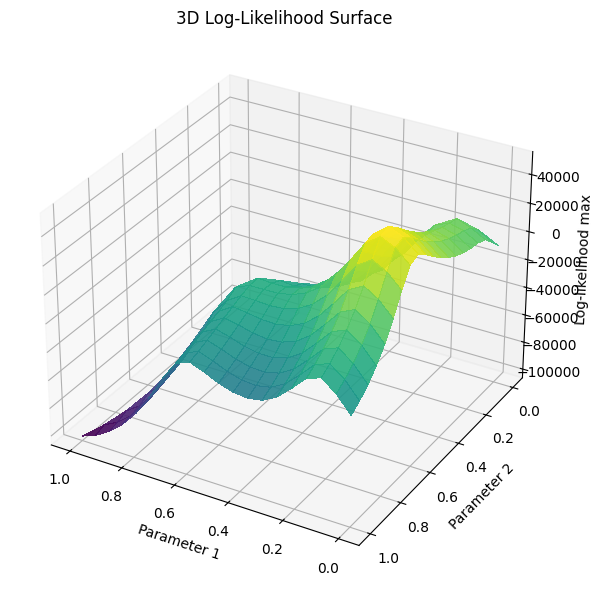

In [ ]:
time = np.linspace(0, 1, 1000)
N = 2

amp = 160.0
t0 = 0.1
rise = 0.03
skew = 5
ybkg = 5.0

burstparams = {
    't0'   : [t0, t0+0.5],
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
x_model, x_counts = simulator.simulate_burst(return_model=True)

# Define ranges for the two parameters
t0_1_range = np.linspace(0, 1, 20)
t0_2_range = np.linspace(0, 1, 20)

# Create a meshgrid of parameter values
P1, t0_2 = np.meshgrid(t0_1_range, t0_2_range)
Z = np.zeros_like(P1)

# Loop through the grid and evaluate log_prob
for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        theta = np.array([P1[i, j], t0_2[i, j]])
        Z[i, j] = log_prob(theta, modelparams, x_counts)  # Or use log_likelihood if separate

# Plot the contour 
plt.figure(figsize=(8, 6))
contour = plt.contourf(P1, t0_2, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='Log Likelihood')
plt.xlabel('Parameter 1')
plt.ylabel('Parameter 2')
plt.title('2D Log-Likelihood Contour skew =5')
plt.show()


############# 3D- plot #######################3

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# plot the surface
surf = ax.plot_surface(
    P1, t0_2, Z,
    rstride=1, cstride=1,
    cmap='viridis',
    linewidth=0, antialiased=False,
    alpha=0.9
)

# add a color‐bar
m = plt.cm.ScalarMappable(cmap='viridis')
m.set_array(Z)
# fig.colorbar(m, shrink=0.5, aspect=10, label='Shifted log-likelihood')

# labels and view angle
ax.set_xlabel('Parameter 1')
ax.set_ylabel('Parameter 2')
ax.set_zlabel('Log-likelihood max')
ax.set_title('3D Log-Likelihood Surface')
ax.view_init(elev=30, azim=120)

plt.tight_layout()
plt.show()

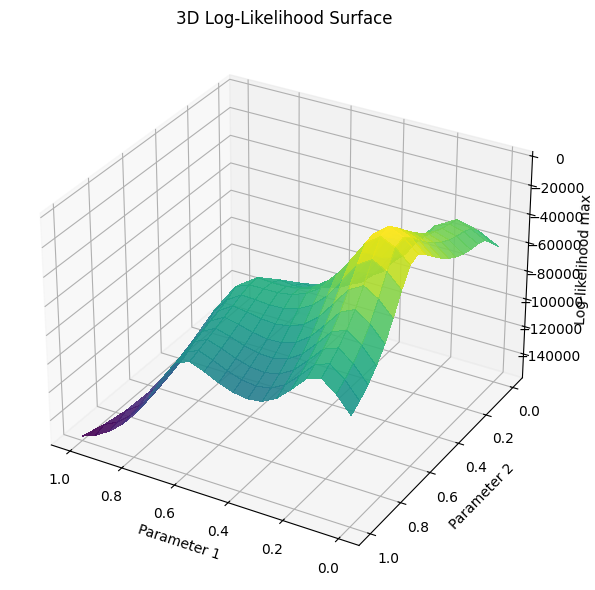